In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score 

In [87]:
RANDOM_STATE = 42

DATASET_PATH = "data_for_class.csv"

pd.set_option('display.float_format', lambda x: '%.2f' % x)

**Целевая переменная**
- `satisfaction`: удовлетворенность клиента полетом, бинарная (*satisfied* или *neutral or dissatisfied*)

**Признаки**
- `Gender` (categorical: _Male_ или _Female_): пол клиента
- `Age` (numeric, int): количество полных лет
- `Customer Type` (categorical: _Loyal Customer_ или _disloyal Customer_): лоялен ли клиент авиакомпании?
- `Type of Travel` (categorical: _Business travel_ или _Personal Travel_): тип поездки
- `Class` (categorical: _Business_ или _Eco_, или _Eco Plus_): класс обслуживания в самолете
- `Flight Distance` (numeric, int): дальность перелета (в милях)
- `Departure Delay in Minutes` (numeric, int): задержка отправления (неотрицательная)
- `Arrival Delay in Minutes` (numeric, int): задержка прибытия (неотрицательная)
- `Inflight wifi service` (categorical, int): оценка клиентом интернета на борту
- `Departure/Arrival time convenient` (categorical, int): оценка клиентом удобство времени прилета и вылета
- `Ease of Online booking` (categorical, int): оценка клиентом удобства онлайн-бронирования
- `Gate location` (categorical, int): оценка клиентом расположения выхода на посадку в аэропорту
- `Food and drink` (categorical, int): оценка клиентом еды и напитков на борту
- `Online boarding` (categorical, int): оценка клиентом выбора места в самолете
- `Seat comfort` (categorical, int): оценка клиентом удобства сиденья
- `Inflight entertainment` (categorical, int): оценка клиентом развлечений на борту
- `On-board service` (categorical, int): оценка клиентом обслуживания на борту
- `Leg room service` (categorical, int): оценка клиентом места в ногах на борту
- `Baggage handling` (categorical, int): оценка клиентом обращения с багажом
- `Checkin service` (categorical, int): оценка клиентом регистрации на рейс
- `Inflight service` (categorical, int): оценка клиентом обслуживания на борту
- `Cleanliness` (categorical, int): оценка клиентом чистоты на борту

In [88]:
df = pd.read_csv(DATASET_PATH)
df.head(10)

,id,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
0,1,Male,48.00,disloyal Customer,Business travel,Business,821.00,2.00,5.00,3.00,...,3.00,5.00,5.00,3.00,2.00,5.00,4.00,5.00,5.00,neutral or dissatisfied
1,2,Female,35.00,Loyal Customer,Business travel,Business,821.00,26.00,39.00,2.00,...,5.00,4.00,5.00,5.00,5.00,5.00,3.00,5.00,5.00,satisfied
2,3,Male,41.00,Loyal Customer,Business travel,Business,853.00,0.00,0.00,4.00,...,5.00,5.00,3.00,3.00,3.00,3.00,4.00,3.00,5.00,satisfied
3,4,Male,50.00,Loyal Customer,Business travel,Business,1905.00,0.00,0.00,2.00,...,4.00,5.00,5.00,5.00,5.00,5.00,3.00,5.00,4.00,satisfied
4,5,Female,49.00,Loyal Customer,Business travel,Business,3470.00,0.00,1.00,3.00,...,5.00,4.00,3.00,3.00,4.00,3.00,3.00,3.00,5.00,satisfied
5,6,Male,43.00,Loyal Customer,Business travel,Business,3788.00,0.00,0.00,4.00,...,5.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,satisfied
6,7,Male,43.00,Loyal Customer,Business travel,Business,1963.00,0.00,0.00,3.00,...,4.00,5.00,5.00,5.00,5.00,5.00,4.00,5.00,4.00,satisfied
7,8,Female,60.00,Loyal Customer,Business travel,Business,853.00,0.00,3.00,4.00,...,4.00,4.00,3.00,3.00,4.00,3.00,3.00,3.00,4.00,satisfied
8,9,Male,50.00,Loyal Customer,Business travel,Business,2607.00,0.00,0.00,4.00,...,2.00,3.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00,neutral or dissatisfied
9,10,Female,38.00,Loyal Customer,Business travel,Business,2822.00,13.00,0.00,2.00,...,5.00,4.00,5.00,5.00,5.00,5.00,3.00,5.00,4.00,satisfied


In [89]:
print('Размер датасета:', df.shape)
print('Количество дубликатов:', df.duplicated().sum(), '\n')
df.info()

Размер датасета: (129880, 24)
Количество дубликатов: 0 

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129549 non-null  str    
 2   Age                                129564 non-null  float64
 3   Customer Type                      129803 non-null  str    
 4   Type of Travel                     129779 non-null  str    
 5   Class                              129764 non-null  str    
 6   Flight Distance                    129786 non-null  float64
 7   Departure Delay in Minutes         129773 non-null  float64
 8   Arrival Delay in Minutes           129371 non-null  float64
 9   Inflight wifi service              129835 non-null  float64
 10  Departure/Arrival time convenient  129831 non-null  float6

In [90]:
df.describe()

,id,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness
count,129880.00,129564.00,129786.00,129773.00,129371.00,129835.00,129831.00,129837.00,129842.00,129830.00,129834.00,129832.00,129833.00,129836.00,129834.00,129832.00,129838.00,129817.00,129843.00
mean,64940.50,40.11,1323.39,15.81,16.65,2.73,3.06,2.76,2.98,3.21,3.26,3.45,3.36,3.39,3.36,3.64,3.31,3.65,3.29
std,37493.27,20.37,4516.19,93.21,109.17,1.36,1.56,1.43,1.31,1.36,1.38,1.35,1.37,1.34,1.36,1.22,1.30,1.22,1.35
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,32470.75,27.00,414.00,0.00,0.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,3.00,3.00,3.00,2.00
50%,64940.50,40.00,846.00,0.00,0.00,3.00,3.00,3.00,3.00,3.00,3.00,4.00,4.00,4.00,4.00,4.00,3.00,4.00,3.00
75%,97410.25,51.00,1744.00,12.00,13.00,4.00,4.00,4.00,4.00,4.00,4.00,5.00,4.00,4.00,4.00,5.00,4.00,5.00,4.00
max,129880.00,621.00,379620.00,22227.00,14006.00,45.00,45.00,45.00,36.00,45.00,40.00,45.00,45.00,45.00,40.00,40.00,45.00,40.00,45.00


In [91]:
df.describe(include='object')

C:\Users\User\AppData\Local\Temp\ipykernel_16432\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Customer Type,Type of Travel,Class,satisfaction
count,129549,129803,129779,129764,129880
unique,2,2,2,3,3
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,65726,106040,89625,62103,58879


## Обработка целевой переменной

In [92]:
print(f'Процент пропусков {df[df['satisfaction'] == '-']['satisfaction'].count() / df['satisfaction'].count() * 100}')

df['satisfaction'].value_counts()

Процент пропусков 20.0


satisfaction
neutral or dissatisfied    58879
satisfied                  45025
-                          25976
Name: count, dtype: int64

In [93]:
df_final = df[df['satisfaction'] == '-'].drop(columns='satisfaction')
print('Размер финальной выборки:', df_final.shape, '\n')

df = df[df['satisfaction'] != '-']
print('Размер основной выборки:', df.shape)

Размер финальной выборки: (25976, 23) 

Размер основной выборки: (103904, 24)


**Распределение классов**

In [94]:
class_mapping = {
    'neutral or dissatisfied': 0,
    'satisfied': 1
}

df['satisfaction'] = df['satisfaction'].map(class_mapping)
df['satisfaction'].value_counts(dropna=False)

satisfaction
0    58879
1    45025
Name: count, dtype: int64

0: 56.67 %
1: 43.33 %


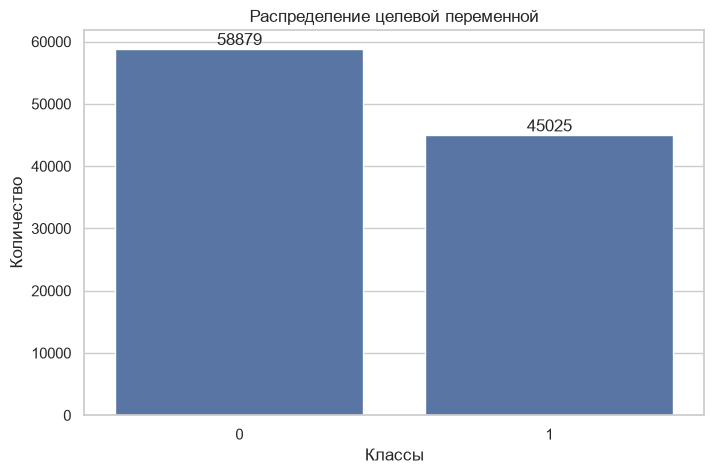

In [95]:
print(f'0: {round(df[df['satisfaction'] == 0]['satisfaction'].count() / df['satisfaction'].count() * 100, 2)} %')
print(f'1: {round(df[df['satisfaction'] == 1]['satisfaction'].count() / df['satisfaction'].count() * 100, 2)} %')

sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='satisfaction', data=df)
ax.bar_label(ax.containers[0])
plt.title('Распределение целевой переменной')
plt.xlabel('Классы')
plt.ylabel('Количество')

plt.show()

## Обработка признаков (не оценки)

In [96]:
df = df.drop(columns='id')
df.info()

<class 'pandas.DataFrame'>
Index: 103904 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103644 non-null  str    
 1   Age                                103643 non-null  float64
 2   Customer Type                      103838 non-null  str    
 3   Type of Travel                     103816 non-null  str    
 4   Class                              103815 non-null  str    
 5   Flight Distance                    103832 non-null  float64
 6   Departure Delay in Minutes         103820 non-null  float64
 7   Arrival Delay in Minutes           103497 non-null  float64
 8   Inflight wifi service              103871 non-null  float64
 9   Departure/Arrival time convenient  103863 non-null  float64
 10  Ease of Online booking             103871 non-null  float64
 11  Gate location                      103873 non-null  flo

In [97]:
#Gender

gender_moda = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(gender_moda)
print(df['Gender'].unique(), '\n')

gender_mapping = {
    'Male': 1,
    'Female': 0
}

df['Gender'] = df['Gender'].map(gender_mapping)
df['Gender'].value_counts(dropna=False)

<StringArray>
['Male', 'Female']
Length: 2, dtype: str 



Gender
0    52850
1    51054
Name: count, dtype: int64

count   103338.00
mean        39.40
std         15.19
min          0.00
25%         27.00
50%         40.00
75%         51.00
max        110.00
Name: Age, dtype: float64


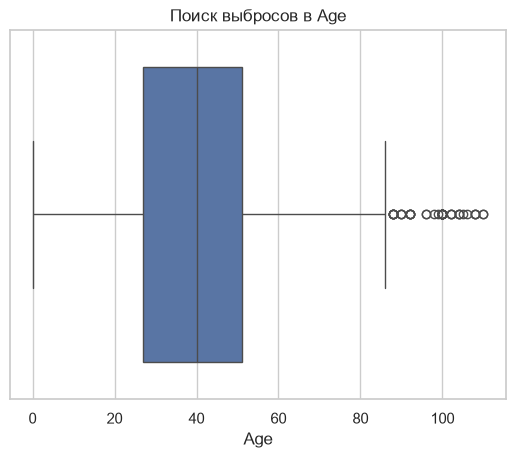

In [98]:
#Age

df = df[(df['Age'] >= 0) & (df['Age'] <= 110)]

print(df['Age'].describe())

sns.boxplot(data=df, x='Age', orient='h')
plt.title('Поиск выбросов в Age')
plt.show()

In [99]:
# Customer Type

df = df[df['Customer Type'].notna()]

customer_type_mapping = {
    'disloyal Customer': 0,
    'Loyal Customer': 1
}

df['Customer Type'] = df['Customer Type'].map(customer_type_mapping)

df['Customer Type'].value_counts(dropna=False)

Customer Type
1    84420
0    18855
Name: count, dtype: int64

In [100]:
# Type of Travel

df = df[df['Type of Travel'].notna()]

type_of_travel_mapping = {
    'Business travel': 1,
    'Personal Travel': 0
}

df['Type of Travel'] = df['Type of Travel'].map(type_of_travel_mapping)

df['Type of Travel'].value_counts(dropna=False)

Type of Travel
1    71141
0    32047
Name: count, dtype: int64

In [101]:
# Class

print(df['Class'].value_counts(dropna=False))

df = df[df['Class'].notna()]

class_mapping_ = {
    'Eco': 0,
    'Eco Plus': 1,
    'Business': 2
}

df['Class'] = df['Class'].map(class_mapping_)

df['Class'].value_counts(dropna=False)


Class
Business    49273
Eco         46396
Eco Plus     7430
NaN            89
Name: count, dtype: int64


Class
2    49273
0    46396
1     7430
Name: count, dtype: int64

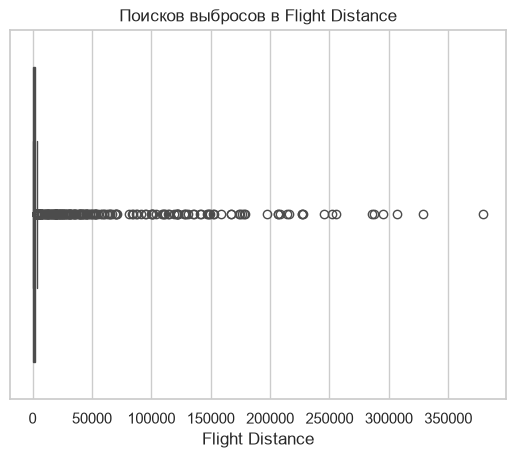

44064     0
73656     1
85305     0
109779    0
Name: satisfaction, dtype: int64


,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
44064,0.00,0.00,0.00
73656,0.00,0.00,0.00
85305,0.00,0.00,0.00
109779,0.00,0.00,0.00


In [102]:
# Flight Distance

df = df[df['Flight Distance'].notna()]

sns.boxplot(data=df, x='Flight Distance', orient='h')
plt.title('Поисков выбросов в Flight Distance')
plt.show()

print(df[df['Flight Distance'] == 0]['satisfaction'])
df[df['Flight Distance'] == 0][['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']]

count   100582.00
mean      1129.10
std        921.76
min         31.00
25%        408.00
50%        814.00
75%       1660.00
max       3739.00
Name: Flight Distance, dtype: float64


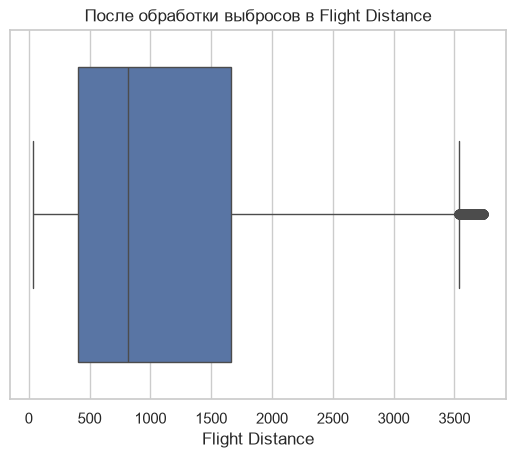

In [103]:
Q1 = df['Flight Distance'].quantile(0.25)
Q3 = df['Flight Distance'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['Flight Distance'] > 0) & (df['Flight Distance'] <= Q3 + 1.5 *IQR)]

print(df['Flight Distance'].describe())
sns.boxplot(data=df, x='Flight Distance', orient='h')
plt.title('После обработки выбросов в Flight Distance')
plt.show()

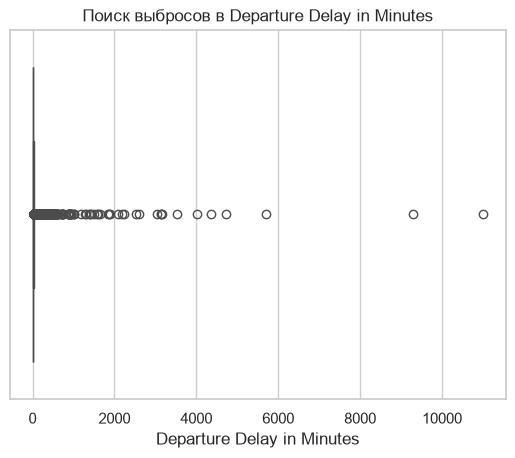

In [104]:
# Departure Delay in Minutes

sns.boxplot(data=df, x='Departure Delay in Minutes', orient='h')
plt.title('Поиск выбросов в Departure Delay in Minutes')
plt.show()

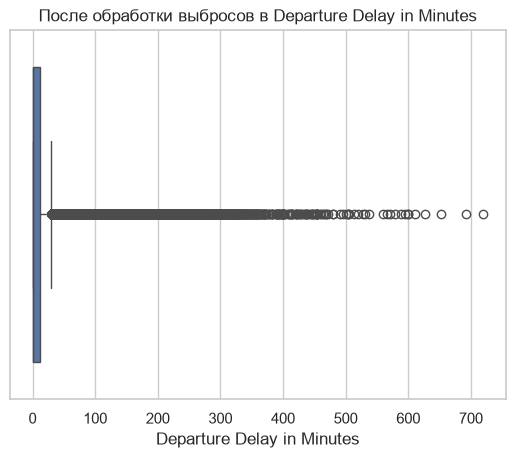

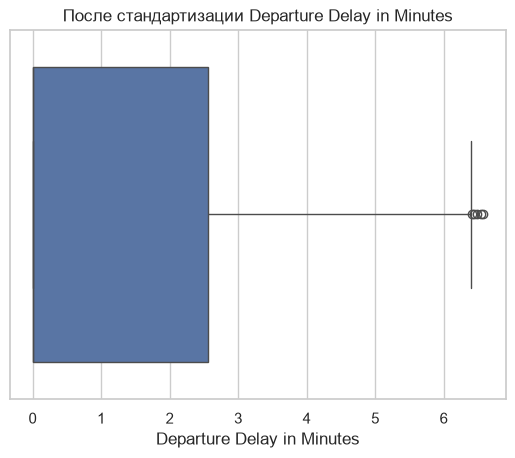

In [105]:
df = df[df['Departure Delay in Minutes'] <= 720]

sns.boxplot(data=df, x='Departure Delay in Minutes', orient='h')
plt.title('После обработки выбросов в Departure Delay in Minutes')
plt.show()

df['Departure Delay in Minutes'] = np.log1p(df['Departure Delay in Minutes'])

sns.boxplot(data=df, x='Departure Delay in Minutes', orient='h')
plt.title('После стандартизации Departure Delay in Minutes')
plt.show()

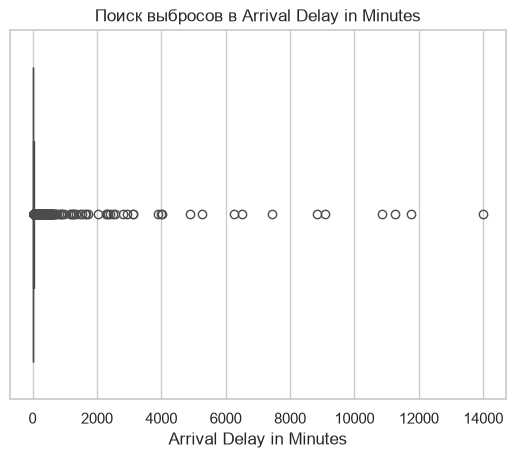

In [106]:
# Arrival Delay in Minutes

df = df[df['Arrival Delay in Minutes'].notna()]

sns.boxplot(data=df, x='Arrival Delay in Minutes', orient='h')
plt.title('Поиск выбросов в Arrival Delay in Minutes')
plt.show()

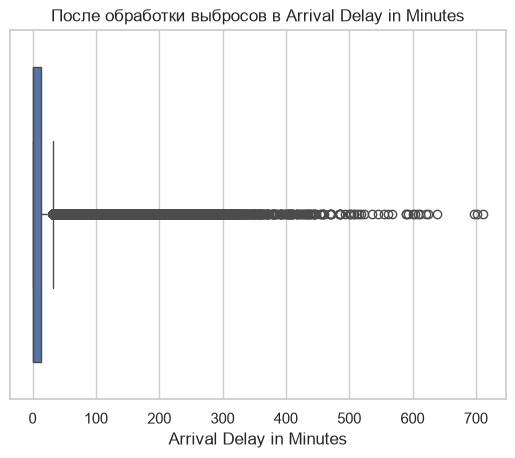

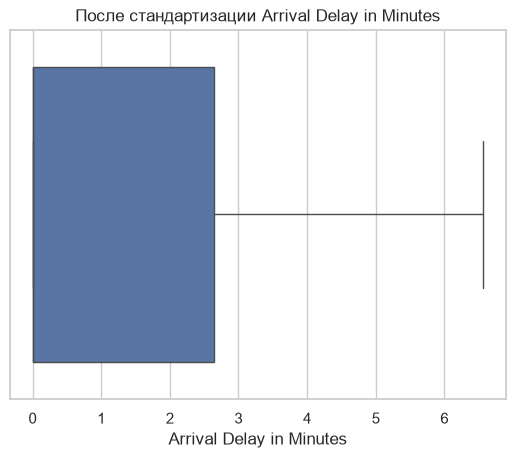

In [107]:
df = df[df['Arrival Delay in Minutes'] < 720]

sns.boxplot(data=df, x='Arrival Delay in Minutes', orient='h')
plt.title('После обработки выбросов в Arrival Delay in Minutes')
plt.show()

df['Arrival Delay in Minutes'] = np.log1p(df['Arrival Delay in Minutes'])

sns.boxplot(data=df, x='Arrival Delay in Minutes', orient='h')
plt.title('После стандартизации Arrival Delay in Minutes')
plt.show()

## Обработка оценок (признаки)

In [108]:
services_list = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

df = df.dropna(subset=services_list)

print('Количесво уникальных значений до обрабротки:', df['Inflight wifi service'].unique(), '\n')

df = df[(df[services_list] <= 5).all(axis=1)]

print('После обработки:')
df['Inflight wifi service'].value_counts(dropna=False)

Количесво уникальных значений до обрабротки: [ 3.  2.  4.  1.  0.  5.  6. 12. 20. 16. 18.  7. 21. 40. 28. 25. 45. 10.
 15.] 

После обработки:


Inflight wifi service
3.00    24756
2.00    24737
4.00    18870
1.00    16977
5.00    10882
0.00     2949
Name: count, dtype: int64

In [109]:
df.info()

<class 'pandas.DataFrame'>
Index: 99171 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             99171 non-null  int64  
 1   Age                                99171 non-null  float64
 2   Customer Type                      99171 non-null  int64  
 3   Type of Travel                     99171 non-null  int64  
 4   Class                              99171 non-null  int64  
 5   Flight Distance                    99171 non-null  float64
 6   Departure Delay in Minutes         99171 non-null  float64
 7   Arrival Delay in Minutes           99171 non-null  float64
 8   Inflight wifi service              99171 non-null  float64
 9   Departure/Arrival time convenient  99171 non-null  float64
 10  Ease of Online booking             99171 non-null  float64
 11  Gate location                      99171 non-null  float64
 12  Food 

In [110]:
print(df.shape)
df.sample(10)

(99171, 23)


,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Inflight wifi service,Departure/Arrival time convenient,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,satisfaction
48357,0,25.00,0,1,0,522.00,0.00,0.00,2.00,5.00,...,2.00,5.00,5.00,3.00,1.00,1.00,2.00,3.00,5.00,0
79600,0,9.00,0,1,0,760.00,2.71,0.69,2.00,2.00,...,2.00,4.00,4.00,3.00,1.00,2.00,4.00,2.00,4.00,0
113634,0,46.00,1,0,0,226.00,0.00,0.00,3.00,4.00,...,5.00,4.00,4.00,4.00,3.00,4.00,3.00,4.00,5.00,0
89362,1,65.00,1,0,0,1587.00,0.00,0.00,3.00,4.00,...,3.00,2.00,2.00,4.00,5.00,4.00,5.00,4.00,2.00,0
128513,1,35.00,1,0,0,646.00,0.00,0.00,3.00,1.00,...,3.00,3.00,3.00,2.00,3.00,2.00,3.00,2.00,3.00,0
94399,0,59.00,1,1,2,3578.00,0.00,0.00,5.00,5.00,...,4.00,5.00,2.00,2.00,2.00,2.00,5.00,2.00,5.00,1
14992,0,65.00,1,0,1,476.00,4.03,3.89,2.00,3.00,...,4.00,4.00,5.00,5.00,2.00,5.00,1.00,5.00,1.00,0
122865,1,40.00,1,1,2,226.00,0.00,0.00,0.00,0.00,...,5.00,5.00,3.00,3.00,1.00,1.00,5.00,3.00,4.00,1
51918,0,38.00,0,1,1,507.00,0.00,2.48,4.00,4.00,...,4.00,1.00,1.00,2.00,5.00,4.00,5.00,5.00,1.00,0
95050,1,57.00,1,0,0,189.00,0.69,0.00,5.00,1.00,...,0.00,5.00,5.00,2.00,5.00,4.00,3.00,4.00,5.00,1


## Обучение

In [111]:
y = df['satisfaction']
X = df.drop(columns=['satisfaction'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Логистическая регрессия**

In [112]:
model_lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print(f'Точность: {round(accuracy_score(y_pred_lr, y_test), 4)}')
print(classification_report(y_test, y_pred_lr))

probabilities_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(y_test, probabilities_lr)
pr_auc_lr = average_precision_score(y_test, probabilities_lr)

print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")

Точность: 0.8785
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     11436
           1       0.87      0.84      0.85      8399

    accuracy                           0.88     19835
   macro avg       0.88      0.87      0.87     19835
weighted avg       0.88      0.88      0.88     19835

ROC-AUC: 0.9279
PR-AUC: 0.9297


**Логистическая регрессия с SGD**

In [113]:
model_sgd = SGDClassifier(loss='log_loss', max_iter=100, random_state=RANDOM_STATE)

model_sgd.fit(X_train_scaled, y_train)

y_pred_sgd = model_sgd.predict(X_test_scaled)

print(f'Точность: {round(accuracy_score(y_pred_sgd, y_test), 4)}')
print(classification_report(y_test, y_pred_sgd))

probabilities_sgd = model_sgd.predict_proba(X_test_scaled)[:, 1]

roc_auc_sgd = roc_auc_score(y_test, probabilities_sgd)
pr_auc_sgd = average_precision_score(y_test, probabilities_sgd)

print(f"ROC-AUC: {roc_auc_sgd:.4f}")
print(f"PR-AUC: {pr_auc_sgd:.4f}")

Точность: 0.8782
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     11436
           1       0.88      0.83      0.85      8399

    accuracy                           0.88     19835
   macro avg       0.88      0.87      0.87     19835
weighted avg       0.88      0.88      0.88     19835

ROC-AUC: 0.9266
PR-AUC: 0.9294


**Логистическая регрессия с CV**

In [ ]:
model_lrcv = LogisticRegressionCV(
    Cs=10, 
    cv=5, 
    max_iter=5000, 
    random_state=RANDOM_STATE,
    scoring='accuracy',
    l1_ratios=(0,),
    use_legacy_attributes=False
)

model_lrcv.fit(X_train_scaled, y_train)

y_pred_lrcv = model_lrcv.predict(X_test_scaled)

print(f'Точность: {round(accuracy_score(y_pred_lrcv, y_test), 4)}')
print(classification_report(y_test, y_pred_lrcv))

probabilities_lrcv = model_lrcv.predict_proba(X_test_scaled)[:, 1]

roc_auc_lrcv = roc_auc_score(y_test, probabilities_lrcv)
pr_auc_lrcv = average_precision_score(y_test, probabilities_lrcv)

print(f"ROC-AUC: {roc_auc_lrcv:.4f}")
print(f"PR-AUC: {pr_auc_lrcv:.4f}")

Точность: 0.8785
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     11436
           1       0.87      0.84      0.85      8399

    accuracy                           0.88     19835
   macro avg       0.88      0.87      0.87     19835
weighted avg       0.88      0.88      0.88     19835

ROC-AUC: 0.9278
PR-AUC: 0.9298
